# **Detection of Leukemia in Blood Cell Images Using Deep Learning and Explainable AI**

# **Downloading Dataset**

In [ ]:
import requests
import zipfile
import io
import os

# The URL for the Brain Tumor MRI Dataset
url = "https://data.mendeley.com/public-api/zip/96sb28ft9n/download/1"

print("Downloading Brain Tumor MRI Dataset... (approx 80MB)")
response = requests.get(url)

if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall("brain_tumor_data")
        print("Extraction complete! Folder created: 'brain_tumor_data'")

    # Inspect the structure (this dataset usually has Training/Testing folders)
    for root, dirs, files in os.walk("brain_tumor_data"):
        if files:
            print(f"Path: {root} | File Count: {len(files)}")
            break # Just show the first main directory
else:
    print(f"Download failed. Status code: {response.status_code}")

Extraction complete! Folder created: 'brain_tumor_data'
Path: brain_tumor_data/Leukemia Classification/training_data/fold_2/hem | File Count: 1096


# **Exploratory Data Analysis**

## **Displaying Images**

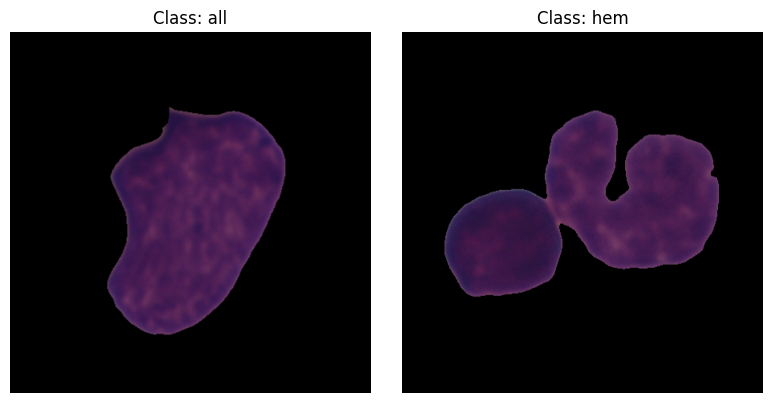

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Correct base path for the Leukemia Classification dataset
# We'll use 'fold_1' as an example, assuming similar structure across folds
base_path = 'brain_tumor_data/Leukemia Classification/training_data/fold_1'
# Correct categories for Leukemia Classification (Acute Lymphoblastic Leukemia and Healthy)
categories = ['all', 'hem']

plt.figure(figsize=(8, 4)) # Adjusted figure size for 2 categories

for i, cat in enumerate(categories):
    folder_path = os.path.join(base_path, cat)
    # Check if the folder exists before listing its contents
    if os.path.exists(folder_path):
        img_name = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_name)

        img = Image.open(img_path)
        plt.subplot(1, 2, i + 1) # Adjusted subplot for 2 categories
        plt.imshow(img)
        plt.title(f"Class: {cat}")
        plt.axis('off')
    else:
        print(f"Warning: Folder not found: {folder_path}")

plt.tight_layout()
plt.show()

## **Data Visualization**

/tmp/ipython-input-721572617.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')


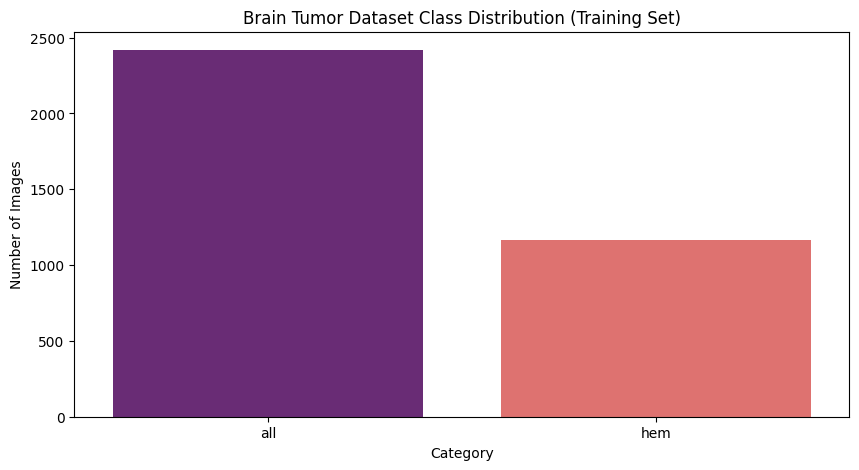

--- Dataset Statistics ---
  Category  Count
0      all   2418
1      hem   1163

Total Images: 3581


In [ ]:
import pandas as pd
import seaborn as sns

stats = []
for cat in categories:
    folder_path = os.path.join(base_path, cat)
    num_files = len(os.listdir(folder_path))
    stats.append({'Category': cat, 'Count': num_files})

df_stats = pd.DataFrame(stats)

# Visualizing class distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')
plt.title('Brain Tumor Dataset Class Distribution (Training Set)')
plt.ylabel('Number of Images')
plt.show()

# Print detailed info
print("--- Dataset Statistics ---")
print(df_stats)
print(f"\nTotal Images: {df_stats['Count'].sum()}")